In [1]:
import os
import numpy as np
import pandas as pd
import cv2
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------------------------
# 1) Lire le CSV
# -------------------------
csv_path = "../../data/dataset_selection_sans_leger.csv"
df = pd.read_csv(csv_path)

assert "path" in df.columns and "label" in df.columns
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)

df["exists"] = df["path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"[WARN] {missing} fichiers manquants — supprimés.")
df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)

In [2]:
# -------------------------
# 2) Preprocessing : crop + CLAHE
# -------------------------
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    arr = np.array(img)
    gray = arr.mean(axis=2)
    mask = gray > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    y0 = max(0, y0 - pad); x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)
    return img.crop((x0, y0, x1 + 1, y1 + 1))

def apply_clahe(img: Image.Image, clip_limit=2.0, tile_grid=(8, 8)):
    """Améliore le contraste local — utile pour les vaisseaux et lésions rétiniennes."""
    arr = np.array(img)
    lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l = clahe.apply(l)
    lab = cv2.merge([l, a, b])
    return Image.fromarray(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))

In [3]:
# -------------------------
# 3) Encoder les labels + split (identique au DenseNet original)
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)
test_df, val_df = train_test_split(
    temp_df, test_size=0.5, random_state=42,
    stratify=temp_df["y"] if num_classes > 1 else None
)
print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

# -------------------------
# 4) Transforms
# Augmentations enrichies par rapport à l'original
# -------------------------
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, shear=5, scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True, do_clahe=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop
        self.do_clahe = do_clahe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.do_crop:
            img = crop_black_border_pil(img)
        if self.do_clahe:
            img = apply_clahe(img)
        if self.transform:
            img = self.transform(img)
        return img, int(row["y"])

train_ds = FundusDataset(train_df, transform=train_tfms)
val_ds   = FundusDataset(val_df,   transform=val_tfms)
test_ds  = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 4966 | Val : 621 | Test : 621


In [4]:
# -------------------------
# 5) Modèle DenseNet-121
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, num_classes)
model = model.to(device)

# ---- Focal Loss ----
# Down-pondère les exemples faciles, focus sur les exemples durs (normaux mal classés)
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha  # tensor de poids par classe (weighted loss)
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, weight=self.alpha, reduction="none", label_smoothing=0.1)
        pt = torch.exp(-ce)
        focal = (1 - pt) ** self.gamma * ce
        return focal.mean() if self.reduction == "mean" else focal.sum()

# Weighted : plus de poids sur les normaux (classe la plus confondue)
# Ordre des classes : diabete=0, glaucome=1, mda=2, normaux=3
class_weights = torch.tensor([1.0, 1.0, 1.0, 1.5]).to(device)

criterion = FocalLoss(alpha=class_weights, gamma=2.0)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)
print("Criterion: Focal Loss (gamma=2, weight normaux=1.5) + label smoothing 0.1")

Device: cuda
Criterion: Focal Loss (gamma=2, weight normaux=1.5) + label smoothing 0.1


In [5]:
# -------------------------
# 6) Fonctions train / eval (identiques à l'original)
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            running_loss += criterion(logits, y).item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

In [6]:
# -------------------------
# 7) Entraînement (même setup que l'original : early stopping patience=11)
# -------------------------
best_val_acc = 0.0
early_stop_patience = 11
epochs_no_improve = 0
epochs = 200
best_model_path = "test_densenet_focal_weighted.pth"

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
          f"lr {current_lr:.2e}")

    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping à l'epoch {epoch}")
        break

print(f"\nMeilleure val acc : {best_val_acc:.4f}")

Epoch 01 | train loss 0.4009 acc 0.7547 | val loss 0.2754 acc 0.8213 | lr 1.00e-04
Epoch 02 | train loss 0.2645 acc 0.8518 | val loss 0.2625 acc 0.8422 | lr 1.00e-04
Epoch 03 | train loss 0.2391 acc 0.8697 | val loss 0.2260 acc 0.8680 | lr 1.00e-04
Epoch 04 | train loss 0.2175 acc 0.8810 | val loss 0.2284 acc 0.8631 | lr 1.00e-04
Epoch 05 | train loss 0.1764 acc 0.9160 | val loss 0.2223 acc 0.8857 | lr 1.00e-04
Epoch 06 | train loss 0.1718 acc 0.9138 | val loss 0.2149 acc 0.8921 | lr 1.00e-04
Epoch 07 | train loss 0.1494 acc 0.9362 | val loss 0.2204 acc 0.8953 | lr 1.00e-04
Epoch 08 | train loss 0.1495 acc 0.9350 | val loss 0.2775 acc 0.8374 | lr 1.00e-04
Epoch 09 | train loss 0.1348 acc 0.9448 | val loss 0.2525 acc 0.8760 | lr 1.00e-04
Epoch 10 | train loss 0.1216 acc 0.9545 | val loss 0.2413 acc 0.8905 | lr 1.00e-04
Epoch 11 | train loss 0.1236 acc 0.9511 | val loss 0.2287 acc 0.8937 | lr 5.00e-05
Epoch 12 | train loss 0.1048 acc 0.9646 | val loss 0.2109 acc 0.9002 | lr 5.00e-05
Epoc

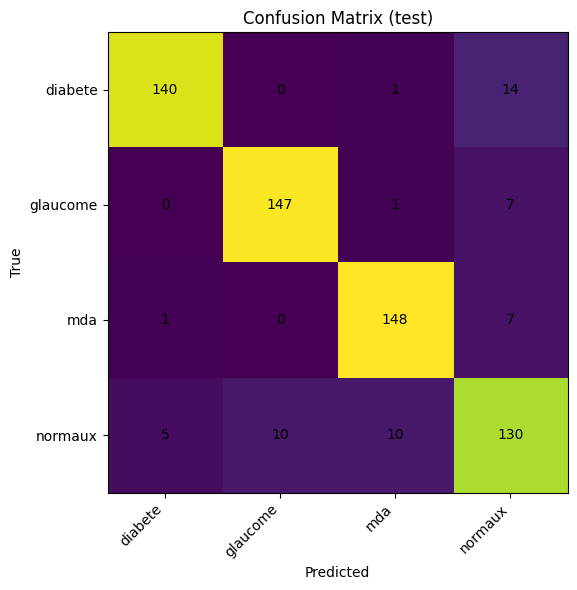

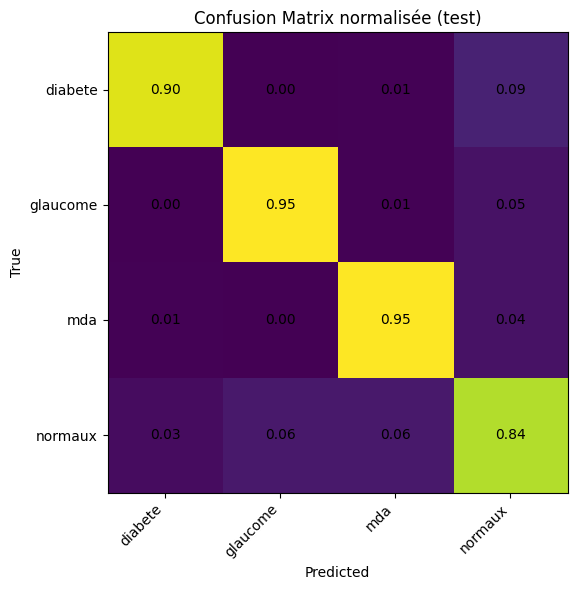


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.9589    0.9032    0.9302       155
    glaucome     0.9363    0.9484    0.9423       155
         mda     0.9250    0.9487    0.9367       156
     normaux     0.8228    0.8387    0.8307       155

    accuracy                         0.9098       621
   macro avg     0.9107    0.9098    0.9100       621
weighted avg     0.9108    0.9098    0.9100       621

AUC-ROC macro (OvR) : 0.9824

--- Rappel scores précédents ---
DenseNet original                 : 93.40%
DenseNet + CLAHE + smoothing      : 92.27%
DenseNet + Focal Loss + weighted  : 90.98%


In [7]:
# -------------------------
# 8) Évaluation sur le test set
# -------------------------
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))

def predict_on_loader(model, loader, device):
    model.eval()
    y_true, y_pred, y_proba = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            probs = torch.softmax(model(x), dim=1)
            y_pred.append(probs.argmax(1).cpu().numpy())
            y_true.append(y.numpy())
            y_proba.append(probs.cpu().numpy())
    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_proba)

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(cm)
    ax.set_xticks(np.arange(len(class_names))); ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm[i,j]:.2f}" if normalize else str(cm[i,j]), ha="center", va="center")
    plt.tight_layout(); plt.show()

y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)
cm = confusion_matrix(y_true, y_pred)

plot_confusion_matrix(cm, list(le.classes_), title="Confusion Matrix (test)")
plot_confusion_matrix(cm, list(le.classes_), title="Confusion Matrix normalisée (test)", normalize=True)

print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))

try:
    auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    print(f"AUC-ROC macro (OvR) : {auc:.4f}")
except Exception as e:
    print(f"AUC-ROC non calculable : {e}")

print("\n--- Rappel scores précédents ---")
print("DenseNet original                 : 93.40%")
print("DenseNet + CLAHE + smoothing      : 92.27%")
print(f"DenseNet + Focal Loss + weighted  : {(y_true == y_pred).mean()*100:.2f}%")

Nombre d'images mal classées : 56


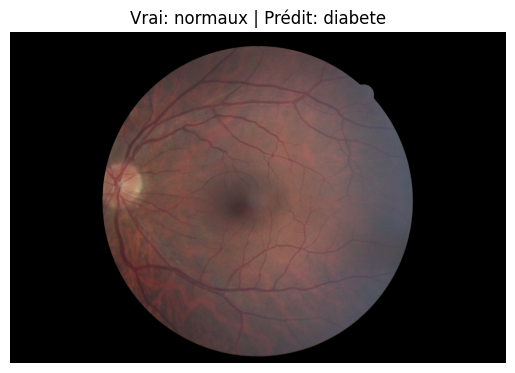

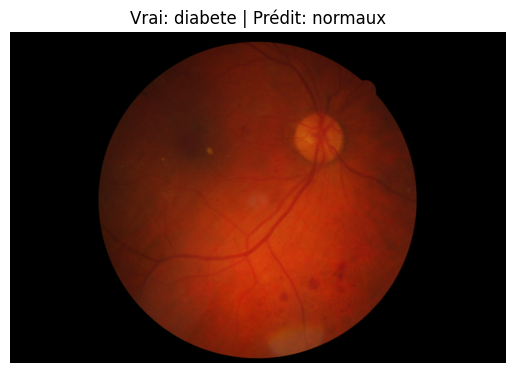

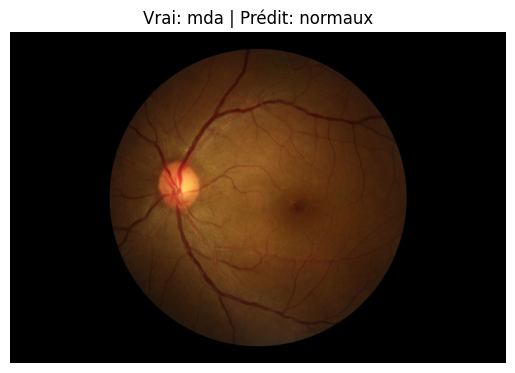

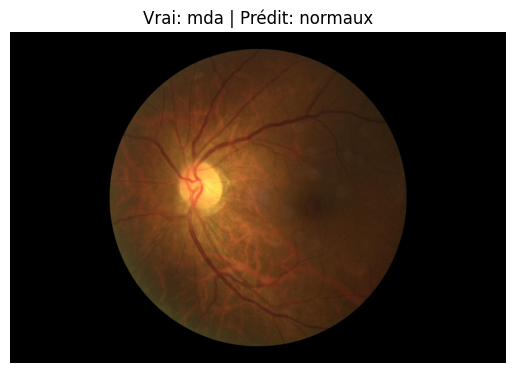

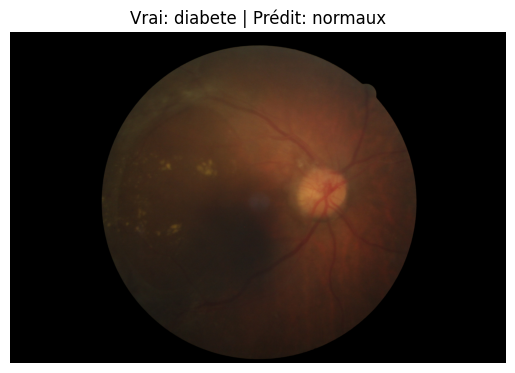

In [8]:
# -------------------------
# 9) Exemples d'images mal classées
# -------------------------
df_test = test_df.reset_index(drop=True)
classes = le.classes_
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")

for idx in misclassified_indices[:5]:
    img_path = df_test.iloc[idx]['path']
    true_label = classes[y_true[idx]]
    pred_label = classes[y_pred[idx]]
    img = Image.open(img_path).convert("RGB")
    plt.imshow(img)
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label}")
    plt.axis("off")
    plt.show()